In [1]:
import pandas as pd
import numpy as np
import pylab as pl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.utils import shuffle

from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss,
)
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from catboost import CatBoostClassifier
import os
import xgboost as xgb

In [2]:
train = pd.read_csv("../Desktop/cmpe_255/linear_models/cell2celltrain.csv")
test = pd.read_csv("../Desktop/cmpe_255/linear_models/cell2cellholdout.csv")

In [3]:
train.info()
train[0:10]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes
5,3000030,No,38.05,682.0,52.0,0.25,0.0,0.0,148.0,-3.1,...,0,1,No,1,30,No,3-Good,Other,Other,Yes
6,3000038,No,31.66,26.0,30.0,0.25,0.0,0.0,60.0,4.0,...,0,9,No,1,30,No,1-Highest,Other,Self,Yes
7,3000042,No,62.13,98.0,66.0,2.48,0.0,0.0,24.0,6.8,...,0,6,No,0,30,No,1-Highest,Other,Professional,No
8,3000046,No,35.30,24.0,35.0,0.00,0.0,0.0,20.0,-0.3,...,0,9,No,0,80,No,1-Highest,Other,Other,Yes
9,3000050,No,81.00,1056.0,75.0,0.00,0.0,0.0,43.0,2.4,...,0,5,No,1,30,No,3-Good,Other,Professional,No


In [4]:
train['Churn'].value_counts()
## churn is either yes or 0, converting to 0 and 1
train['Churn'] = train['Churn'].map({'Yes': 1, 'No': 0})
test['Churn'] = test['Churn'].map({'Yes': 1, 'No': 0})
print(train['Churn'])

0        1
1        1
2        0
3        0
4        1
        ..
51042    1
51043    0
51044    1
51045    0
51046    0
Name: Churn, Length: 51047, dtype: int64


In [5]:
## Missing data handling
print(train.columns[train.isna().any()])
print(train.isna().sum()[train.isna().sum() > 0])

## clearly, the missing values are small subset, no need to drop any row or column
## here, I will go ahead and handle the missing data instead.
###
    # for numeric values, impute median, since it was shown to bo robust against skewing
    # for categorical values, impute with an "Unknown" (for now)
###


Index(['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge',
       'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls',
       'PercChangeMinutes', 'PercChangeRevenues', 'ServiceArea', 'Handsets',
       'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2'],
      dtype='object')
MonthlyRevenue           156
MonthlyMinutes           156
TotalRecurringCharge     156
DirectorAssistedCalls    156
OverageMinutes           156
RoamingCalls             156
PercChangeMinutes        367
PercChangeRevenues       367
ServiceArea               24
Handsets                   1
HandsetModels              1
CurrentEquipmentDays       1
AgeHH1                   909
AgeHH2                   909
dtype: int64


In [6]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
print(num_cols, "\n", cat_cols)

['CustomerID', 'Churn', 'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'RetentionCalls', 'RetentionOffersAccepted', 'ReferralsMadeBySubscriber', 'IncomeGroup', 'AdjustmentsToCreditRating'] 
 ['ServiceArea', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle', 'HandsetPrice', 'MadeCallToRetentionTeam',

In [7]:
## the id col serves no purpose other than unique identification of the row
id_cols = ['CustomerID']
feature_num_cols = []
for c in num_cols:
    if c not in id_cols:
        feature_num_cols.append(c)

In [8]:
for col in feature_num_cols:
    if train[col].isna().any():
        train[col + "_was_missing"] = train[col].isna().astype("int8")
        if col in test.columns:
            test[col + '_was_missing'] = test[col].isna().astype('int8')
        else:
            test[col + '_was_missing'] = 0
        train[col] = train[col].fillna(train[col].median())
        if col in test.columns:
            test[col] = test[col].fillna(test[col].median())
for col in cat_cols:
    if train[col].isna().any():
        train[col + "_was_missing"] = train[col].isna().astype("int8")
        train[col] = train[col].fillna("Unknown")

In [9]:
test[feature_num_cols].isna().sum().sum()

np.int64(20000)

In [10]:
print("Total NaNs in train:", train.isna().sum().sum())
print("Total NaNs in test:", test.isna().sum().sum())

print("\nSample dtypes:")
print(train.dtypes.head(20))


Total NaNs in train: 0
Total NaNs in test: 20004

Sample dtypes:
CustomerID                 int64
Churn                      int64
MonthlyRevenue           float64
MonthlyMinutes           float64
TotalRecurringCharge     float64
DirectorAssistedCalls    float64
OverageMinutes           float64
RoamingCalls             float64
PercChangeMinutes        float64
PercChangeRevenues       float64
DroppedCalls             float64
BlockedCalls             float64
UnansweredCalls          float64
CustomerCareCalls        float64
ThreewayCalls            float64
ReceivedCalls            float64
OutboundCalls            float64
InboundCalls             float64
PeakCallsInOut           float64
OffPeakCallsInOut        float64
dtype: object


In [11]:
# Definitive multi-category categorical features for Cell2Cell dataset
onehot_cols = [
    "CreditRating",
    "PrizmCode",
    "Occupation",
    "IncomeGroup",
    "ServiceArea",
    "ServiceClass",
    "HandsetPriceGroup",
    "HandsetModel",
    "PayMethod",
    "ServiceType",
    "TenureGroup",
    "DwellingType",
    "EthnicGroup",
    "Education",
    "HHStatus",
    "PrizmSocialGroup",
    "PrizmUrbanicity",
    "Homeownership",
]
onehot_cols = [c for c in onehot_cols if c in train.columns]
onehot_cols


['CreditRating',
 'PrizmCode',
 'Occupation',
 'IncomeGroup',
 'ServiceArea',
 'Homeownership']

In [12]:
for col in onehot_cols:
    train[col] = train[col].astype('category')
    if col in test.columns:
        test[col] = test[col].astype('category')
train_ohe = pd.get_dummies(train, columns=onehot_cols, prefix=onehot_cols, drop_first=False)
test_ohe  = pd.get_dummies(test,  columns=onehot_cols, prefix=onehot_cols, drop_first=False)

cols_for_test = [c for c in train_ohe.columns if c != "Churn"]

test_ohe = test_ohe.reindex(columns=cols_for_test, fill_value=0)


In [13]:
print("Train shape after OHE:", train_ohe.shape)
print("Test shape after OHE:", test_ohe.shape)

print("Train NaNs:", train_ohe.isna().sum().sum())
print("Test  NaNs:", test_ohe.isna().sum().sum())


Train shape after OHE: (51047, 845)
Test shape after OHE: (20000, 844)
Train NaNs: 0
Test  NaNs: 0


In [14]:
# Convert any remaining Yes/No object columns to 0/1 so that LightGBM sees only numeric features

yes_no_cols_extra = []
for col in train_ohe.columns:
    if train_ohe[col].dtype == "object":
        vals = set(train_ohe[col].dropna().unique())
        if vals.issubset({"Yes", "No"}):
            yes_no_cols_extra.append(col)

print("Additional Yes/No columns being converted:", yes_no_cols_extra)

for col in yes_no_cols_extra:
    train_ohe[col] = train_ohe[col].map({"No": 0, "Yes": 1}).astype("int8")
    if col in test_ohe.columns:
        test_ohe[col] = test_ohe[col].map({"No": 0, "Yes": 1}).astype("int8")


# HandsetPrice to numeric
if "HandsetPrice" in train_ohe.columns:
    train_ohe["HandsetPrice"] = pd.to_numeric(train_ohe["HandsetPrice"], errors="coerce")
if "HandsetPrice" in test_ohe.columns:
    test_ohe["HandsetPrice"] = pd.to_numeric(test_ohe["HandsetPrice"], errors="coerce")

# Fill any NaNs with median from train
if "HandsetPrice" in train_ohe.columns:
    hp_median = train_ohe["HandsetPrice"].median()
    train_ohe["HandsetPrice"] = train_ohe["HandsetPrice"].fillna(hp_median)
    if "HandsetPrice" in test_ohe.columns:
        test_ohe["HandsetPrice"] = test_ohe["HandsetPrice"].fillna(hp_median)
print("Remaining object dtypes in train after conversion:",
      train_ohe.select_dtypes(include="object").columns.tolist())

Additional Yes/No columns being converted: ['ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle', 'MadeCallToRetentionTeam']
Remaining object dtypes in train after conversion: ['MaritalStatus']


In [15]:
binary_fix_cols = ["MaritalStatus"]

for col in binary_fix_cols:
    if col in train_ohe.columns:
        # Map Yes/No to 1/0; anything else becomes NaN
        mapped = train_ohe[col].map({"No": 0, "Yes": 1})
        # Treat Unknown / other as 0 (non-Yes); we already have <col>_was_missing flags anyway
        train_ohe[col] = mapped.fillna(0).astype("int8")
    
    if col in test_ohe.columns:
        mapped_test = test_ohe[col].map({"No": 0, "Yes": 1})
        test_ohe[col] = mapped_test.fillna(0).astype("int8")

print(
    "Remaining object dtypes in train after ALL conversions:",
    train_ohe.select_dtypes(include="object").columns.tolist()
)


Remaining object dtypes in train after ALL conversions: []


In [16]:
feature_cols = [c for c in train_ohe.columns if c not in ['Churn', 'CustomerID']]

In [17]:
X = train_ohe[feature_cols]
y = train_ohe['Churn'].astype(int)

X_holdout = test_ohe[feature_cols]

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, stratify=y, random_state=1)

X_train.shape, X_val.shape

((40837, 843), (10210, 843))

In [18]:
lgb_model = lgb.LGBMClassifier(
    objective="binary",
    class_weight = "balanced",
    n_estimators=3000,
    learning_rate=0.015,
    num_leaves=128,          # more complex trees than default 31
    max_depth=-1,
    min_data_in_leaf=30,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=1,
    random_state=42,
    n_jobs=-1,
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

print("Best iteration:", lgb_model.best_iteration_)
print("Best AUC:", lgb_model.best_score_["valid_0"]["auc"])


[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Info] Number of positive: 11769, number of neg

In [19]:
## disappointing results, trying CatBoost now
cb_model = CatBoostClassifier(
    depth=6,
    learning_rate=0.05,
    iterations=2000,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=1,
    od_type="Iter",
    od_wait=50,   # early stopping patience
    verbose=100,
    class_weights=[1.0, 2.5]
)

cb_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)
# Probabilities and hard predictions
y_val_proba_cb = cb_model.predict_proba(X_val)[:, 1]
y_val_pred_cb  = (y_val_proba_cb >= 0.5).astype(int)

print("CatBoost AUC:      ", roc_auc_score(y_val, y_val_proba_cb))
print("CatBoost Logloss:  ", log_loss(y_val, y_val_proba_cb))
print("CatBoost Accuracy: ", accuracy_score(y_val, y_val_pred_cb))

print("\nClassification report (CatBoost):\n")
print(classification_report(y_val, y_val_pred_cb))

print("Confusion matrix (CatBoost):")
print(confusion_matrix(y_val, y_val_pred_cb))


0:	test: 0.6223017	best: 0.6223017 (0)	total: 69.6ms	remaining: 2m 19s
100:	test: 0.6688623	best: 0.6688623 (100)	total: 1.14s	remaining: 21.5s
200:	test: 0.6766642	best: 0.6766642 (200)	total: 2.43s	remaining: 21.7s
300:	test: 0.6837396	best: 0.6837580 (299)	total: 3.6s	remaining: 20.3s
400:	test: 0.6870360	best: 0.6871988 (394)	total: 5.11s	remaining: 20.4s
500:	test: 0.6889191	best: 0.6889191 (500)	total: 6.8s	remaining: 20.4s
600:	test: 0.6895920	best: 0.6898277 (585)	total: 8.41s	remaining: 19.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6901959719
bestIteration = 647

Shrink model to first 648 iterations.
CatBoost AUC:       0.6901959718752607
CatBoost Logloss:   0.6282011259700729
CatBoost Accuracy:  0.6349657198824682

Classification report (CatBoost):

              precision    recall  f1-score   support

           0       0.81      0.63      0.71      7268
           1       0.41      0.64      0.50      2942

    accuracy                          

In [20]:
## okay, better results are gotten from the catboost model, now just for fun, i am trying xgboost

dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)
dtest  = xgb.DMatrix(X_holdout)


params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "eta": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "lambda": 2.0,
    "alpha": 0.0,
    "tree_method": "hist",
    "random_state": 42,
    "scale_pos_weight": 2.47
}
evals = [(dtrain, "train"), (dval, "valid")]

xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=3000,
    evals=evals,
    early_stopping_rounds=100,
    verbose_eval=100
)
##hyperparameter tuning
pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]  # imbalance ratio
print(pos_weight)


[0]	train-auc:0.64142	valid-auc:0.61592
[100]	train-auc:0.75861	valid-auc:0.68136
[200]	train-auc:0.79341	valid-auc:0.68632
[300]	train-auc:0.81878	valid-auc:0.68759
[392]	train-auc:0.83864	valid-auc:0.68708
2.469878494349562


In [21]:
y_val_proba = xgb_model.predict(dval)
y_val_pred  = (y_val_proba >= 0.5).astype(int)

print("XGBoost AUC:", roc_auc_score(y_val, y_val_proba))
print("XGBoost Logloss:", log_loss(y_val, y_val_proba))
print("XGBoost Accuracy:", accuracy_score(y_val, y_val_pred))

print("\nClassification report (XGBoost):")
print(classification_report(y_val, y_val_pred))


XGBoost AUC: 0.6870030037709419
XGBoost Logloss: 0.6214226991612815
XGBoost Accuracy: 0.6462291870714986

Classification report (XGBoost):
              precision    recall  f1-score   support

           0       0.81      0.66      0.73      7268
           1       0.42      0.61      0.50      2942

    accuracy                           0.65     10210
   macro avg       0.61      0.64      0.61     10210
weighted avg       0.70      0.65      0.66     10210



In [22]:
xgb_model.get_score(importance_type='cover')


{'MonthlyRevenue': 1222.45556640625,
 'MonthlyMinutes': 1725.1302490234375,
 'TotalRecurringCharge': 1706.9100341796875,
 'DirectorAssistedCalls': 854.8238525390625,
 'OverageMinutes': 991.503173828125,
 'RoamingCalls': 1294.1796875,
 'PercChangeMinutes': 1700.2630615234375,
 'PercChangeRevenues': 967.0284423828125,
 'DroppedCalls': 1069.82080078125,
 'BlockedCalls': 704.0101318359375,
 'UnansweredCalls': 749.9168701171875,
 'CustomerCareCalls': 1500.109619140625,
 'ThreewayCalls': 1049.0125732421875,
 'ReceivedCalls': 962.999755859375,
 'OutboundCalls': 705.0794677734375,
 'InboundCalls': 1120.9072265625,
 'PeakCallsInOut': 700.4708862304688,
 'OffPeakCallsInOut': 903.072509765625,
 'DroppedBlockedCalls': 917.3947143554688,
 'CallForwardingCalls': 6885.951171875,
 'CallWaitingCalls': 1027.93603515625,
 'MonthsInService': 2261.60986328125,
 'UniqueSubs': 3070.545166015625,
 'ActiveSubs': 2741.21484375,
 'Handsets': 2860.29638671875,
 'HandsetModels': 2360.8798828125,
 'CurrentEquipment

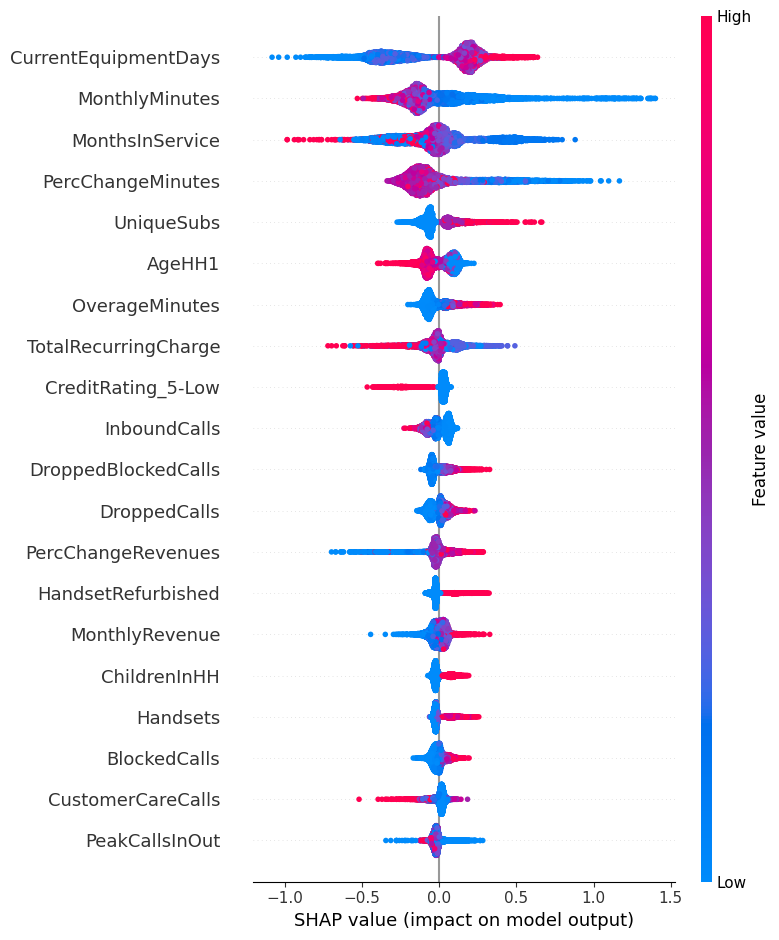

In [23]:
xgb_model.save_model("xgb_model.json")

import xgboost as xgb
xgb_shap_model = xgb.Booster()
xgb_shap_model.load_model("xgb_model.json")

import shap
explainer = shap.TreeExplainer(xgb_shap_model)
shap_values = explainer(X_val)

shap.summary_plot(shap_values, X_val)


In [24]:
import json

config = json.loads(xgb_shap_model.save_config())
learner = config["learner"]
attrs = learner.get("attributes", {})
learner_params = learner.setdefault("learner_model_param", {})
if "base_score" not in learner_params and "base_score" in attrs:
    learner_params["base_score"] = attrs["base_score"]
    xgb_shap_model.load_config(json.dumps(config))

explainer = shap.TreeExplainer(xgb_shap_model)

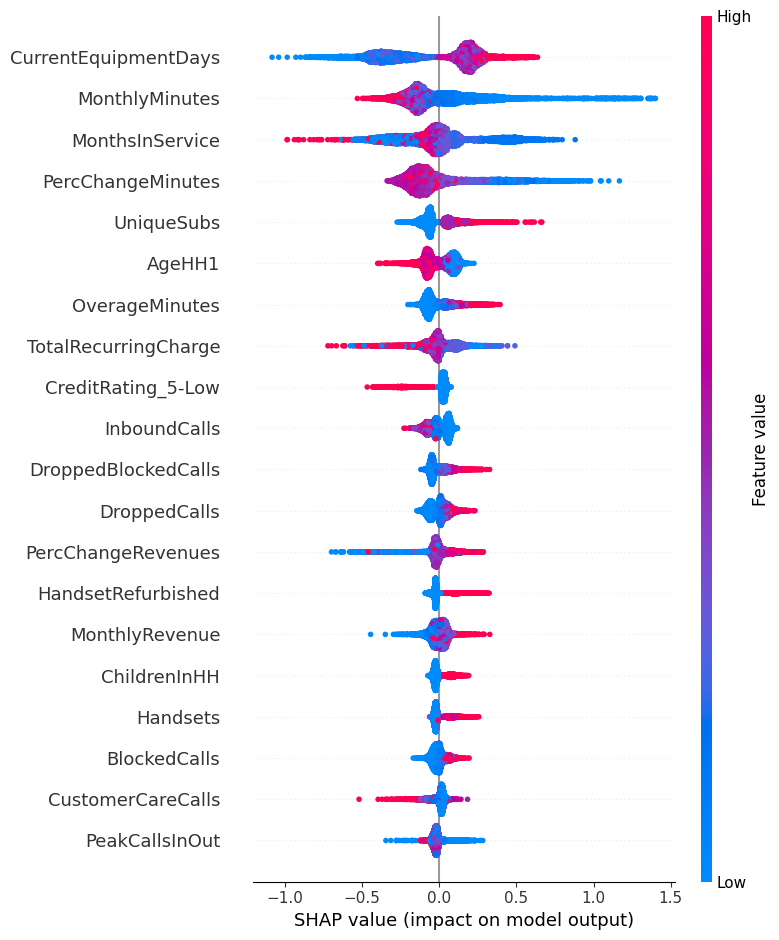

In [25]:
import shap
explainer = shap.TreeExplainer(xgb_model)          # xgb_model is the Booster
shap_values = explainer(X_val)
shap.summary_plot(shap_values, X_val)